# Testing whether the litter model is fixed

This notebook tests that the fix to the litter integration model has successfully fixed
the bugs identified in the [bug identification notebook](./litter_validation.ipynb).

In [2]:
%%bash
# Install the example data directory from the Virtual Ecosystem package
# This is currently using my desktop, but this should change in future (probably)
ve_run --install-example /Users/jc2017/Desktop

# Rename config (and out) to original_config to make it clearer that it is unchanged
mv /Users/jc2017/Desktop/ve_example/config /Users/jc2017/Desktop/ve_example/original_config
mv /Users/jc2017/Desktop/ve_example/out /Users/jc2017/Desktop/ve_example/original_out

Example directory created at:
/Users/jc2017/Desktop/ve_example


## Setting up models (again)

The same steps are taken to set up the model runs as in the previous notebook.

In [3]:
import tomllib

import tomli_w

with open("/Users/jc2017/Desktop/ve_example/original_config/ve_run.toml", "rb") as f:
    general_config = tomllib.load(f)

general_config["abiotic_simple"]["static"] = True
general_config["hydrology"]["static"] = True
general_config["soil"]["static"] = True
general_config["animal"]["static"] = True

with open("/Users/jc2017/Desktop/ve_example/original_config/ve_run.toml", "wb") as f:
    tomli_w.dump(general_config, f)

In [4]:
with open(
    "/Users/jc2017/Desktop/ve_example/original_config/plant_config.toml", "rb"
) as f:
    plant_config = tomllib.load(f)

plant_config["plants"]["static"] = True
plant_config["plants"].setdefault("constants", {})
plant_config["plants"]["constants"].setdefault("PlantsConsts", {})
plant_config["plants"]["constants"]["PlantsConsts"][
    "per_stem_annual_mortality_probability"
] = 0.0

with open(
    "/Users/jc2017/Desktop/ve_example/original_config/plant_config.toml", "wb"
) as f:
    tomli_w.dump(plant_config, f)

## Doubling the above-ground metabolic litter decay rate

Again we double the decay rate of the above ground metabolic litter pool to see how this
changes the simulation results.

In [5]:
%%bash
cp -r /Users/jc2017/Desktop/ve_example/original_config /Users/jc2017/Desktop/ve_example/increased_meta_decay_config

mkdir /Users/jc2017/Desktop/ve_example/increased_meta_decay_out

In [6]:
with open(
    "/Users/jc2017/Desktop/ve_example/increased_meta_decay_config/ve_run.toml", "rb"
) as f:
    general_config = tomllib.load(f)

general_config["litter"].setdefault("constants", {})
general_config["litter"]["constants"].setdefault("LitterConsts", {})
general_config["litter"]["constants"]["LitterConsts"][
    "litter_decay_constant_metabolic_above"
] = 0.16

with open(
    "/Users/jc2017/Desktop/ve_example/increased_meta_decay_config/ve_run.toml", "wb"
) as f:
    tomli_w.dump(general_config, f)

In [7]:
%%bash
ve_run /Users/jc2017/Desktop/ve_example/original_config \
    --outpath /Users/jc2017/Desktop/ve_example/original_out \
    --logfile /Users/jc2017/Desktop/ve_example/original_out/original.log

Starting Virtual Ecosystem simulation.
Logging to: /Users/jc2017/Desktop/ve_example/original_out/original.log
* Loading configuration
* Saved compiled configuration: /Users/jc2017/Desktop/ve_example/original_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic_simple, animal, litter, plants
* Saved model initial state
* Starting simulation
100%|██████████| 24/24 [00:02<00:00,  8.58it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


In [8]:
%%bash
ve_run /Users/jc2017/Desktop/ve_example/increased_meta_decay_config \
    --outpath /Users/jc2017/Desktop/ve_example/increased_meta_decay_out \
    --logfile /Users/jc2017/Desktop/ve_example/increased_meta_decay_out/increased_decay.log

Starting Virtual Ecosystem simulation.
Logging to: /Users/jc2017/Desktop/ve_example/increased_meta_decay_out/increased_decay.log
* Loading configuration
* Saved compiled configuration: /Users/jc2017/Desktop/ve_example/increased_meta_decay_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic_simple, animal, litter, plants
* Saved model initial state
* Starting simulation
100%|██████████| 24/24 [00:02<00:00,  8.68it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


We start by (again) checking the total mineralisation of carbon. This now works and values are always
positive

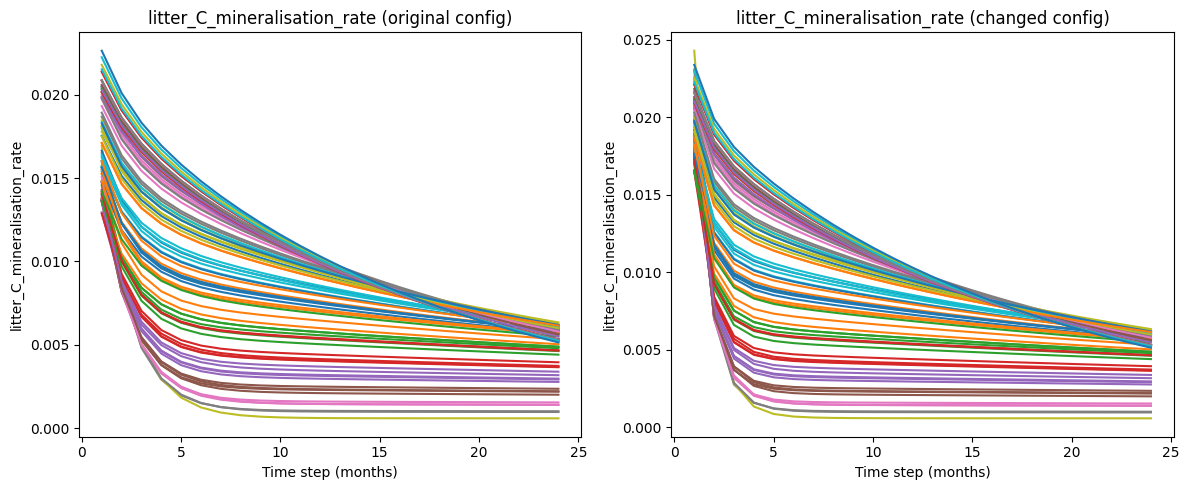

In [9]:
import matplotlib.pyplot as plt
import xarray

original = xarray.load_dataset(
    "/Users/jc2017/Desktop/ve_example/original_out/all_continuous_data.nc"
)
increased_above_meta_decay = xarray.load_dataset(
    "/Users/jc2017/Desktop/ve_example/increased_meta_decay_out/all_continuous_data.nc"
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_C_mineralisation_rate"])
ax1.set_title("litter_C_mineralisation_rate (original config)")
ax1.set_ylabel("litter_C_mineralisation_rate")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_meta_decay["time_index"],
    increased_above_meta_decay["litter_C_mineralisation_rate"],
)
ax2.set_title("litter_C_mineralisation_rate (changed config)")
ax2.set_ylabel("litter_C_mineralisation_rate")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()

The carbon nitrogen ratios also now show plausible behaviours for the increased decay
rate case.

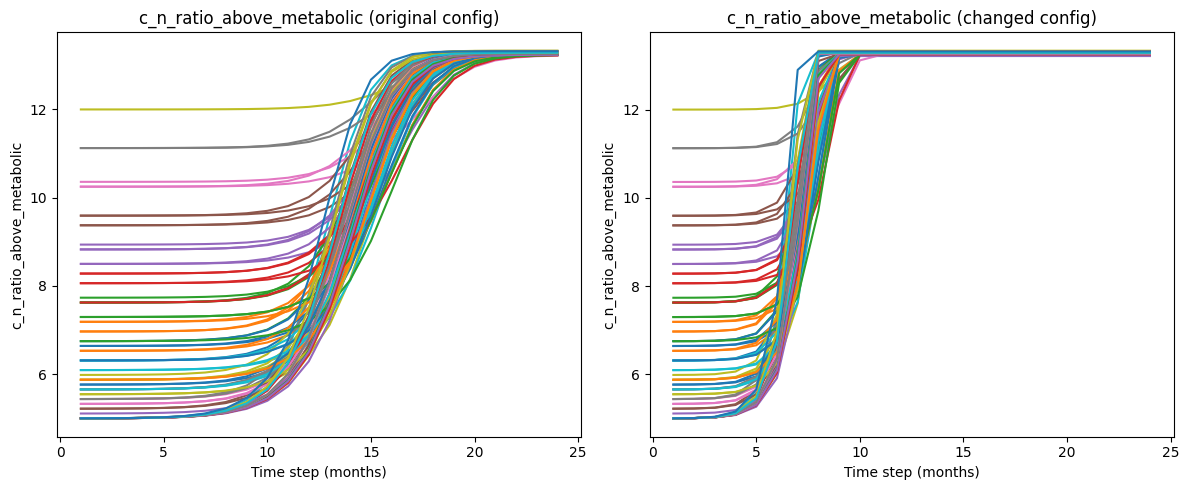

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["c_n_ratio_above_metabolic"])
ax1.set_title("c_n_ratio_above_metabolic (original config)")
ax1.set_ylabel("c_n_ratio_above_metabolic")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_meta_decay["time_index"],
    increased_above_meta_decay["c_n_ratio_above_metabolic"],
)
ax2.set_title("c_n_ratio_above_metabolic (changed config)")
ax2.set_ylabel("c_n_ratio_above_metabolic")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()

Finally, the above ground metabolic litter pools now all show trajectories that don't
include impossible (i.e. negative values)

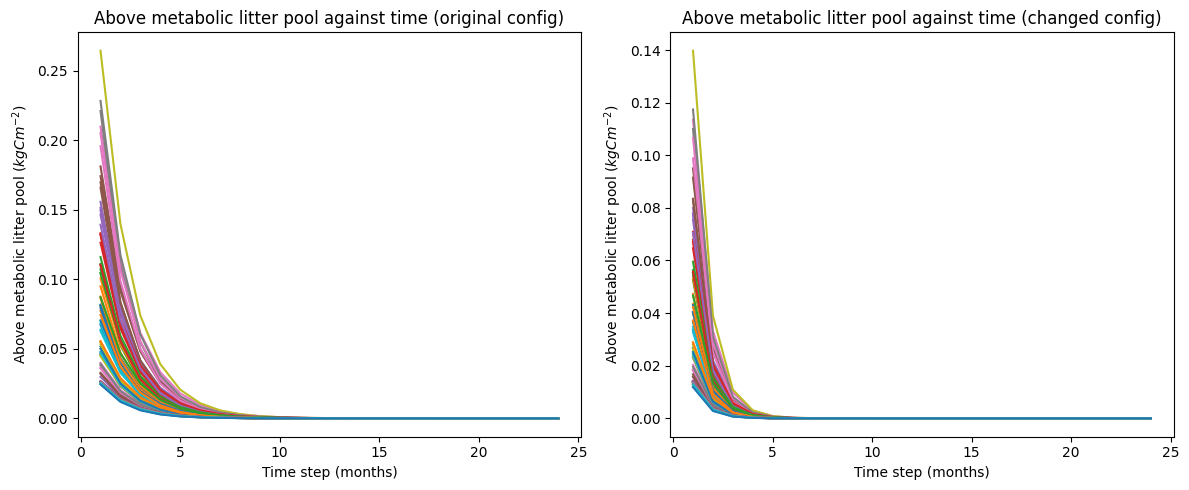

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_pool_above_metabolic"])
ax1.set_title("Above metabolic litter pool against time (original config)")
ax1.set_ylabel("Above metabolic litter pool ($kg C m^{-2}$)")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_meta_decay["time_index"],
    increased_above_meta_decay["litter_pool_above_metabolic"],
)
ax2.set_title("Above metabolic litter pool against time (changed config)")
ax2.set_ylabel("Above metabolic litter pool ($kg C m^{-2}$)")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()